---

# Chapter 3 - Hypothesis Testing

---

## Imports & Data Load

This cell imports everything needed for Chapter 3.
Run this first before any other cell in this notebook.


In [1]:
# ═══════════════════════════════════════════════════════════════
# CHAPTER 3 — IMPORTS & DATA LOAD
# All imports and data loading for this chapter in one cell.
# ═══════════════════════════════════════════════════════════════

# ── Standard libraries ────────────────────────────────────────
import pandas as pd
import numpy as np
import os, sys

# ── Visualisation ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Statistical testing ───────────────────────────────────────
from scipy import stats

# ── Ensure src/ is on the path ────────────────────────────────
sys.path.insert(0, os.path.abspath('..'))

# ── src modules ───────────────────────────────────────────────
from src.config      import *          # ALPHA, PALETTE, DENY_COLOR, APPR_COLOR, GOLD_COLOR, etc.
from src.data_loader import load_processed
from src.viz         import save_fig, fmt_currency, add_avg_line
from src.stats_utils import run_anova, run_chisquare, run_ttest

# ── Load data ─────────────────────────────────────────────────
df = load_processed(verbose=True)

print(f"\n✓ Chapter 3 ready")
print(f"  Significance level α = {ALPHA}")
print(f"  Dataset : {df.shape[0]:,} rows × {df.shape[1]} columns")


 config loaded | project root: C:\Users\Administrator\Desktop\insurance-claim-fraud-detection
 Processed data loaded: 10,000 rows × 49 columns
  IS_DENIED: 503 denied (5.03%)

✓ Chapter 3 ready
  Significance level α = 0.05
  Dataset : 10,000 rows × 49 columns


---

## 3.0 Statistical Testing Framework

Each hypothesis test follows this protocol:
1. State H₀ and H₁
2. Check assumptions (normality, variance)
3. Run parametric test + non-parametric backup
4. Compute effect size
5. Decision at α = 0.05
6. Interpret for research

> **α = 0.05:** p < 0.05 → reject H₀. p ≥ 0.05 → fail to reject H₀ (we do not "accept" it).

---

## 3.1 Normality Check — Prerequisite


 Saved → reports/fig08_normality_qq.png


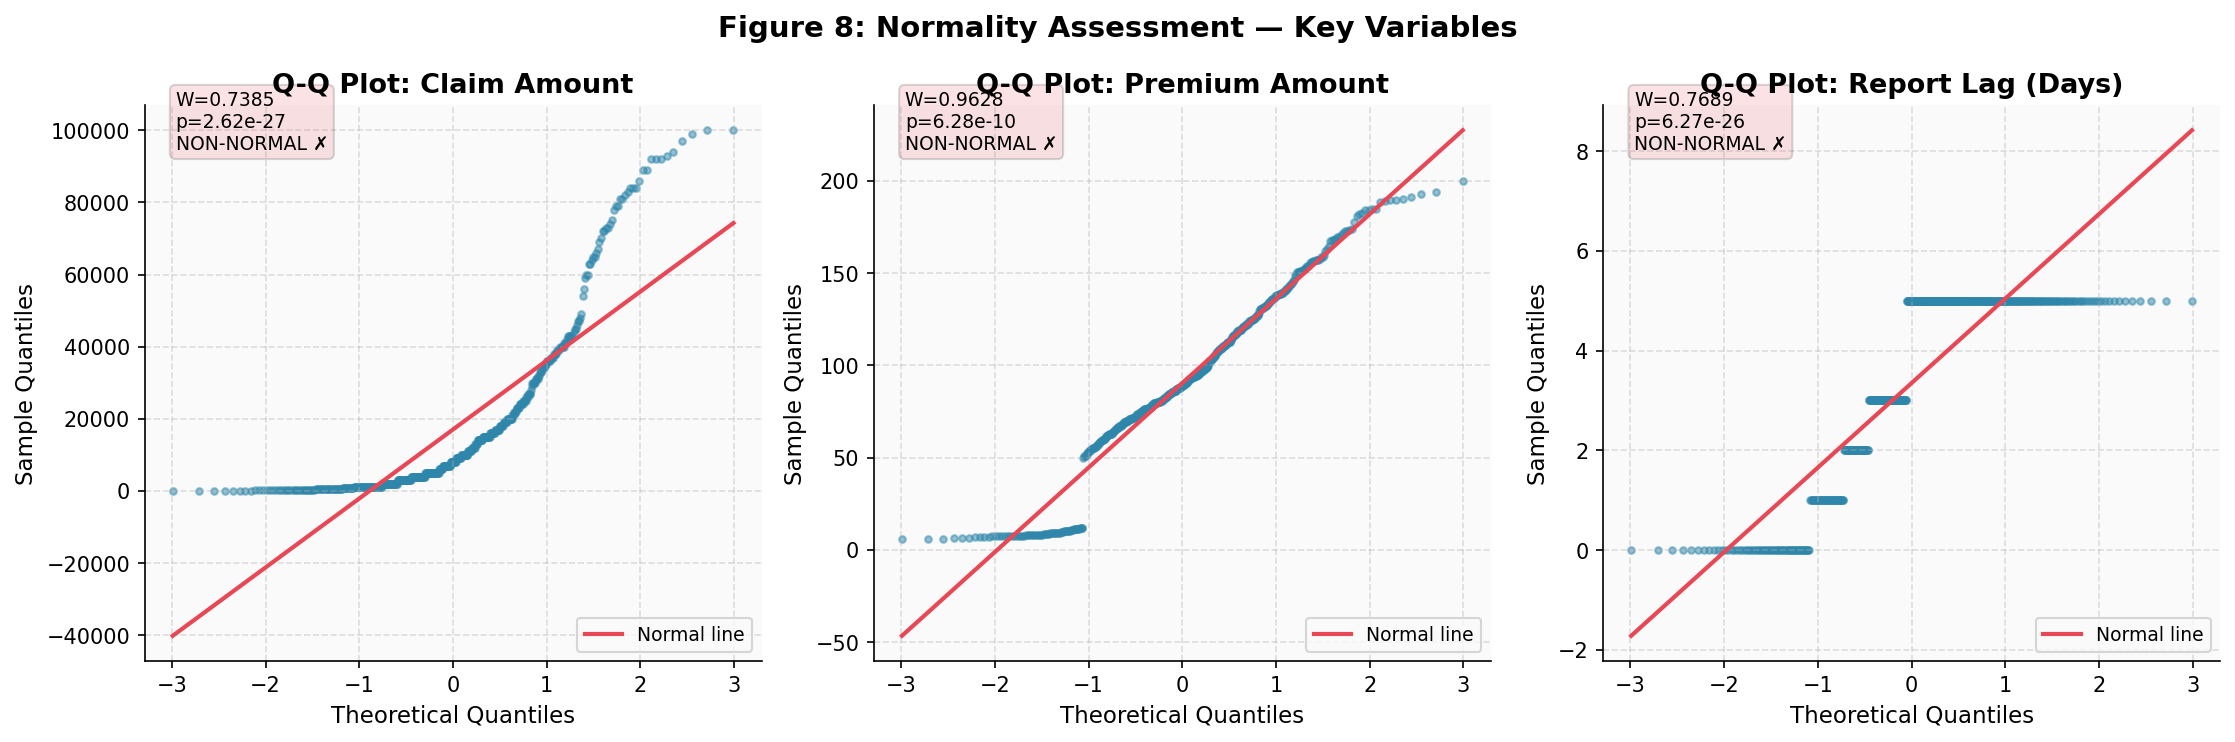

Variable                           W      p-value               Result
──────────────────────────────────────────────────────────────────────
  CLAIM_AMOUNT                0.7385     2.62e-27 Non-normal ✗ → use backup
  PREMIUM_AMOUNT              0.9628     6.28e-10 Non-normal ✗ → use backup
  REPORT_LAG_DAYS             0.7689     6.27e-26 Non-normal ✗ → use backup


In [4]:
# ═══════════════════════════════════════════════════════════════
# 3.1 — NORMALITY TESTING (Shapiro-Wilk + Q-Q plots)
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Figure 8: Normality Assessment — Key Variables', fontsize=14, fontweight='bold')

vars_to_test = [
    ('CLAIM_AMOUNT',    'Claim Amount'),
    ('PREMIUM_AMOUNT',  'Premium Amount'),
    ('REPORT_LAG_DAYS', 'Report Lag (Days)'),
]
normality_results = {}

for i, (col, label) in enumerate(vars_to_test):
    sample      = df[col].dropna().sample(500, random_state=RANDOM_STATE)
    stat, p     = stats.shapiro(sample)
    normality_results[col] = {'W': stat, 'p': p}

    (osm, osr), (slope, intercept, r) = stats.probplot(sample, dist='norm')
    axes[i].scatter(osm, osr, color=APPR_COLOR, alpha=0.5, s=10)
    line_x = np.array([osm.min(), osm.max()])
    axes[i].plot(line_x, slope*line_x+intercept, color=DENY_COLOR, linewidth=2, label='Normal line')
    decision = "NORMAL ✓" if p > ALPHA else "NON-NORMAL ✗"
    col_d    = '#43AA8B' if p > ALPHA else DENY_COLOR
    axes[i].text(
        0.05, 0.92,
        f"W={stat:.4f}\n"
        f"p={p:.2e}\n"
        f"{decision}",
        transform=axes[i].transAxes,
        fontsize=9,
        bbox=dict(boxstyle='round', facecolor=col_d, alpha=0.15)
    )

    axes[i].set_title(f'Q-Q Plot: {label}')
    axes[i].set_xlabel('Theoretical Quantiles')
    axes[i].set_ylabel('Sample Quantiles')
    axes[i].legend(fontsize=9)

save_fig('fig08_normality_qq.png')
plt.show()

print(f"{'Variable':<25} {'W':>10} {'p-value':>12} {'Result':>20}")
print("─" * 70)
for col, res in normality_results.items():
    verdict = "Normal ✓" if res['p'] > ALPHA else "Non-normal ✗ → use backup"
    print(f"  {col:<23} {res['W']:>10.4f} {res['p']:>12.2e} {verdict:>20}")
    

**All variables are non-normal** (p < 0.001). ANOVA is used with caution — it is robust at n > 1,000
due to the Central Limit Theorem. Kruskal-Wallis and Mann-Whitney U run as non-parametric backups.

---

## 3.2 H1 — Claim Amount Differs Across Insurance Types

> **H₀:** Mean claim amount is equal across all 6 insurance types
> **H₁:** At least one type differs significantly
> **Test:** One-way ANOVA + Kruskal-Wallis


  ANOVA: H1 — Claim Amount by Insurance Type
  F-statistic      :   5,229.7752
  ANOVA p-value    :   0.0000e+00
  Eta-squared (η²) :       0.7235
  Kruskal-Wallis H :    8661.2350
  Kruskal p-value  :   0.0000e+00
  α                : 0.05
  Decision         : Reject H₀ 

 Saved → reports/fig09_h1_anova.png


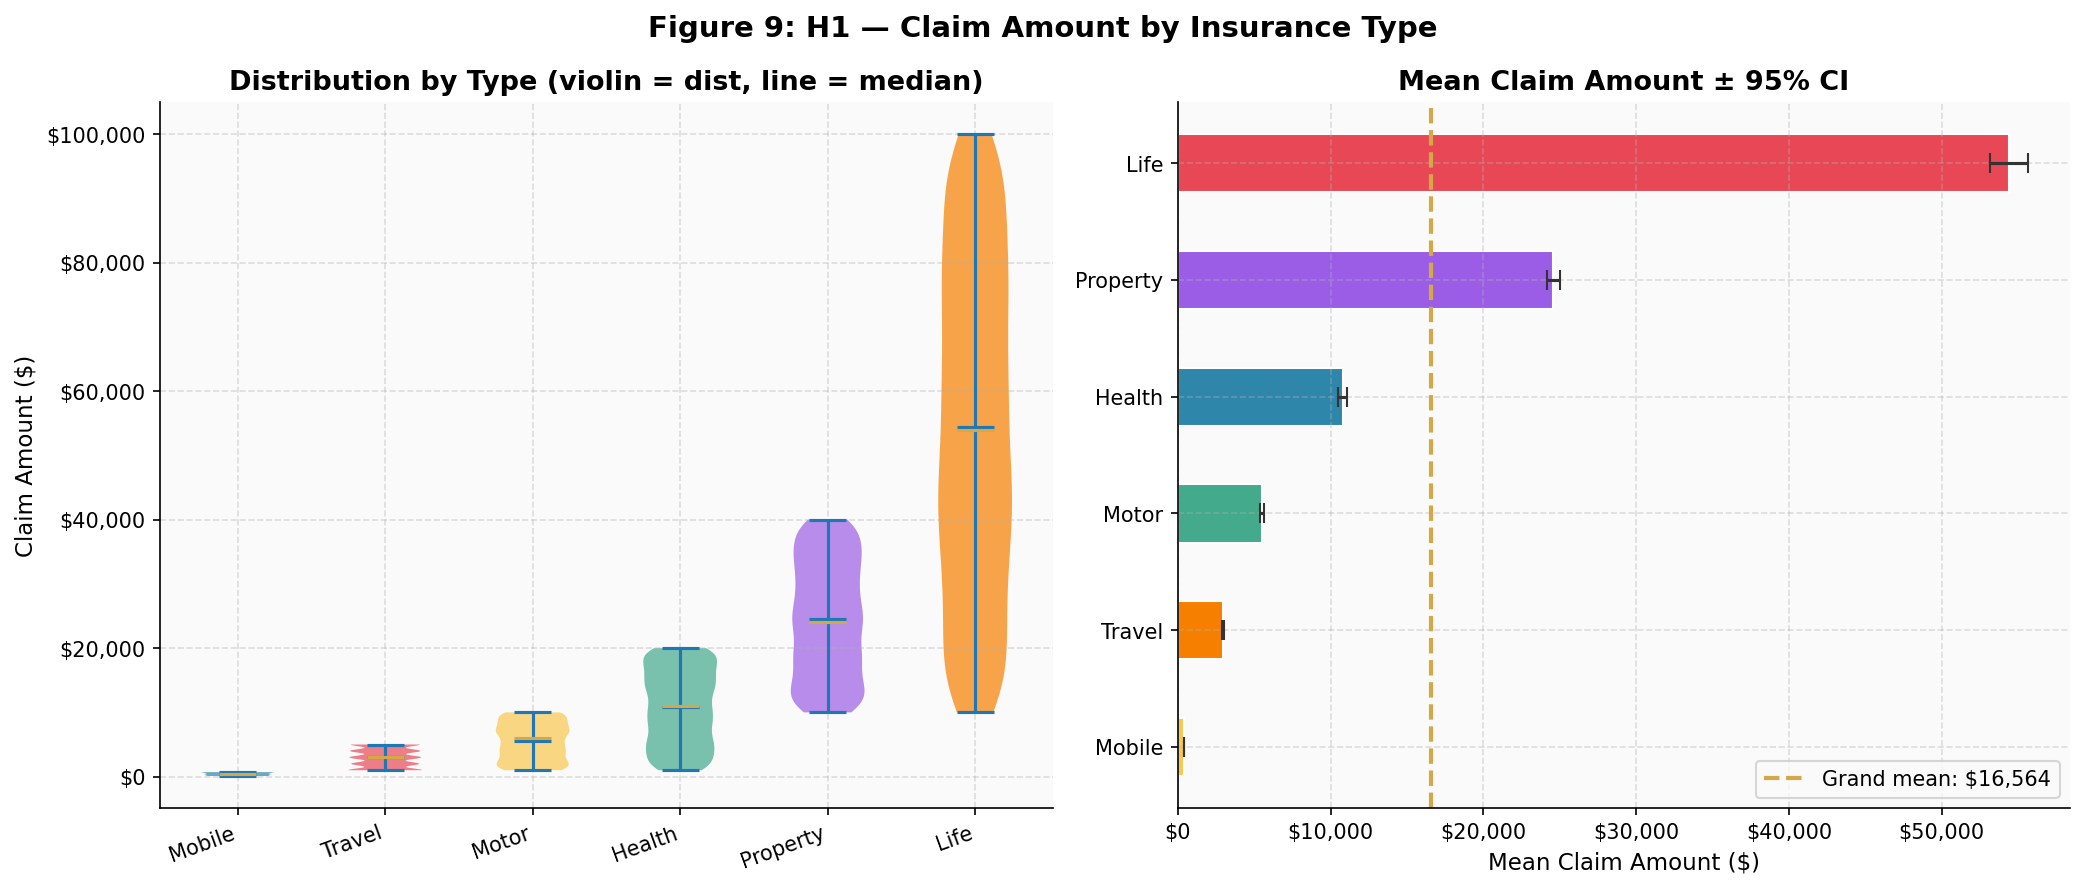

In [5]:
# ═══════════════════════════════════════════════════════════════
# 3.2 — H1: ONE-WAY ANOVA (claim amount by insurance type)
# ═══════════════════════════════════════════════════════════════

# Run test via src.stats_utils
h1_results = run_anova(df, group_col='INSURANCE_TYPE',
                        value_col='CLAIM_AMOUNT',
                        label='H1 — Claim Amount by Insurance Type')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 9: H1 — Claim Amount by Insurance Type', fontsize=14, fontweight='bold')

type_order = df.groupby('INSURANCE_TYPE')['CLAIM_AMOUNT'].median().sort_values().index.tolist()
plot_data  = [df[df['INSURANCE_TYPE']==t]['CLAIM_AMOUNT'].values for t in type_order]
parts = axes[0].violinplot(plot_data, positions=range(len(type_order)),
                             showmedians=True, showmeans=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(PALETTE[i % len(PALETTE)])
    pc.set_alpha(0.7)
parts['cmedians'].set_color(GOLD_COLOR)
axes[0].set_xticks(range(len(type_order)))
axes[0].set_xticklabels(type_order, rotation=20, ha='right')
axes[0].set_title('Distribution by Type (violin = dist, line = median)')
axes[0].set_ylabel('Claim Amount ($)')
fmt_currency(axes[0], 'y')

type_stats = df.groupby('INSURANCE_TYPE')['CLAIM_AMOUNT'].agg(['mean','std','count'])
type_stats['ci95'] = 1.96 * type_stats['std'] / np.sqrt(type_stats['count'])
type_stats = type_stats.sort_values('mean', ascending=True)
hb = axes[1].barh(type_stats.index, type_stats['mean'], xerr=type_stats['ci95'],
                    color=[TYPE_COLORS[t] for t in type_stats.index],
                    edgecolor='white', height=0.5,
                    error_kw=dict(ecolor='#333', capsize=5, linewidth=1.5))
add_avg_line(axes[1], df['CLAIM_AMOUNT'].mean(),
             label=f"Grand mean: ${df['CLAIM_AMOUNT'].mean():,.0f}", orient='v')
axes[1].set_title('Mean Claim Amount ± 95% CI')
axes[1].set_xlabel('Mean Claim Amount ($)')
axes[1].legend()
fmt_currency(axes[1], 'x')

save_fig('fig09_h1_anova.png')
plt.show()


**Result: REJECT H₀** (F=5,229.78, p < 0.001). Insurance type explains substantial variance in claim
amount — driven by Life ($54,386) vs Mobile ($407). **Insurance type must be included as a model feature.**

---

## 3.3 H2 — Denial Rate Independent of Risk Segmentation

> **H₀:** Denial is independent of risk segment (H/M/L)
> **H₁:** Denial rate differs by risk group
> **Test:** Pearson Chi-square


  Chi-Square: H2 — Denial Rate by Risk Segment
  χ² statistic  :       3.2634
  p-value       :   1.9559e-01
  Degrees of freedom: 2
  Cramér's V    :       0.0181
  α             : 0.05
  Decision      : Fail to reject H₀

 Saved → reports/fig10_h2_chisquare.png


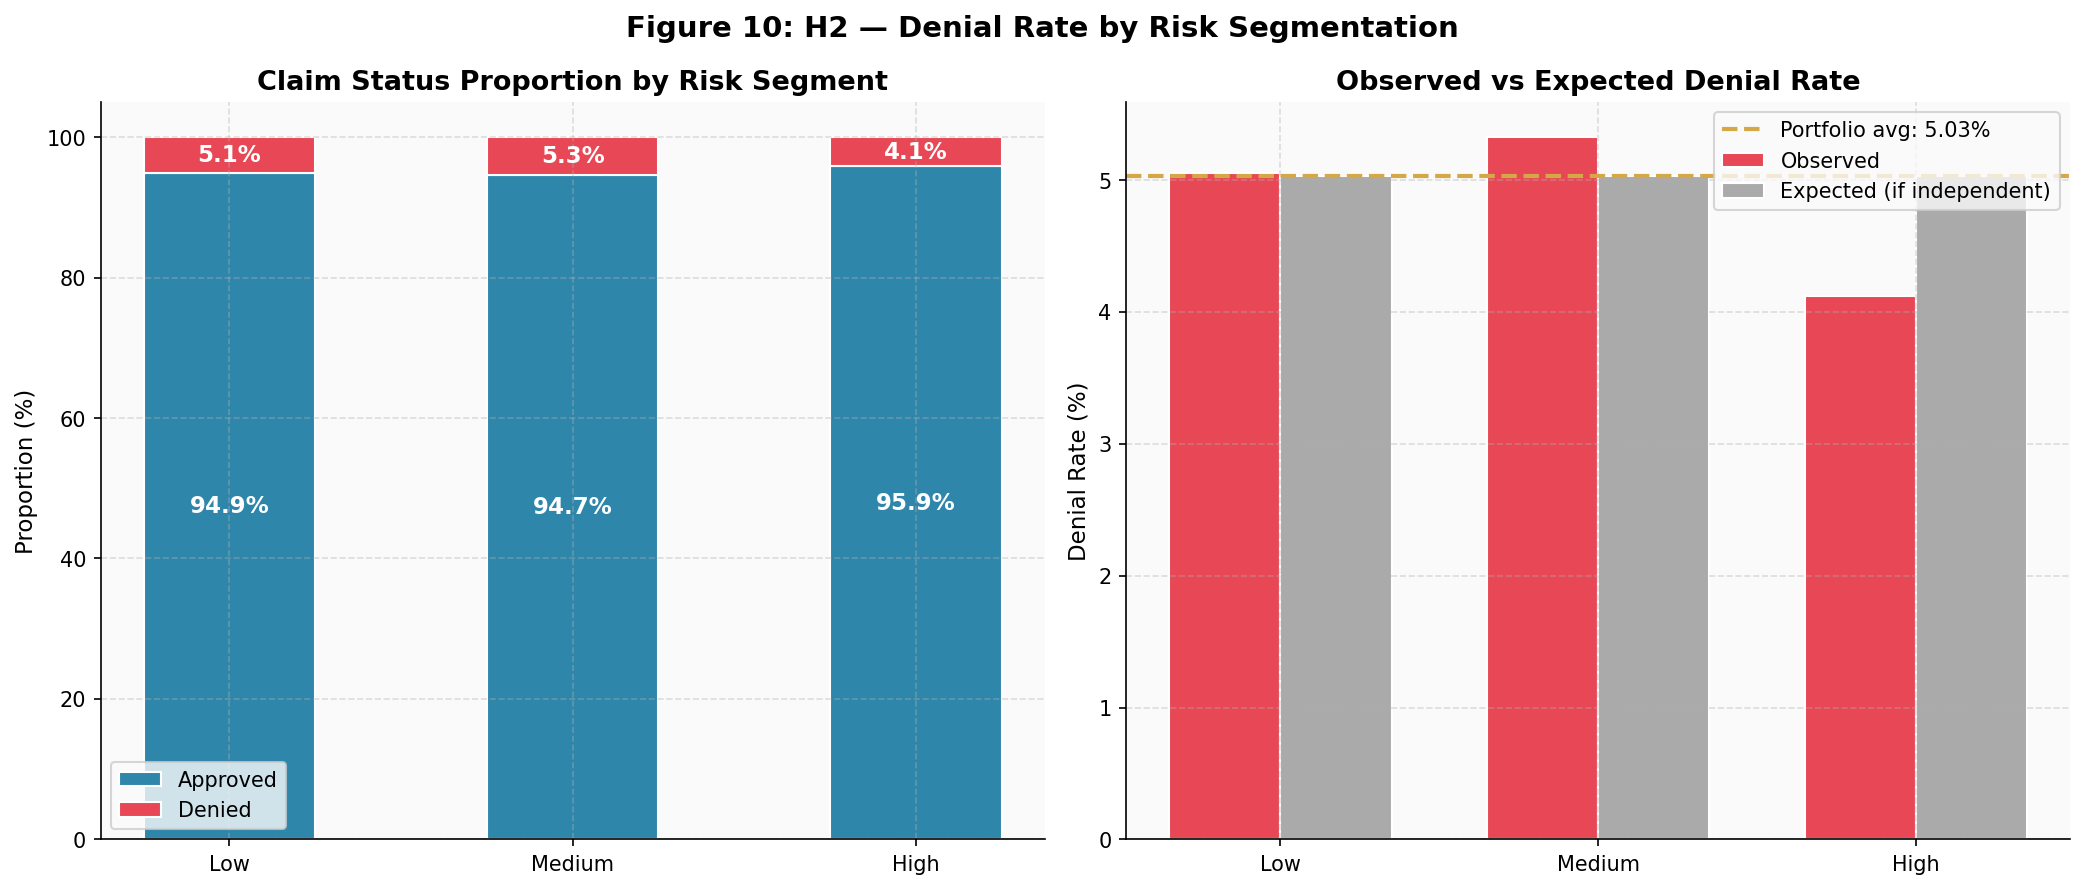

Chi-square Test Results (H2)
────────────────────────────────────────────────────────────
Chi2 statistic : 3.2634
Degrees of freedom : 2
p-value : 1.9559e-01


In [7]:
# ═══════════════════════════════════════════════════════════════
# 3.3 — H2: CHI-SQUARE (denial vs risk segment)
# ═══════════════════════════════════════════════════════════════

h2_results = run_chisquare(
    df,
    group_col='RISK_LABEL',
    target_col='CLAIM_STATUS',
    label='H2 — Denial Rate by Risk Segment'
)

ct_test = h2_results['contingency_table']

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 10: H2 — Denial Rate by Risk Segmentation',
             fontsize=14, fontweight='bold')

# Stacked bar
ct_pct = ct_test.div(ct_test.sum(axis=1), axis=0) * 100
ct_pct = ct_pct.reindex(RISK_SEGMENTS)
bottom = np.zeros(len(RISK_SEGMENTS))
for col, color, lbl in [('A', APPR_COLOR, 'Approved'),
                        ('D', DENY_COLOR, 'Denied')]:
    vals = ct_pct[col].values
    bars = axes[0].bar(RISK_SEGMENTS, vals, bottom=bottom,
                       color=color, label=lbl, width=0.5, edgecolor='white')
    for bar, val, bot in zip(bars, vals, bottom):
        if val > 1:
            axes[0].text(bar.get_x()+bar.get_width()/2, bot+val/2,
                         f'{val:.1f}%', ha='center', va='center',
                         color='white', fontweight='bold', fontsize=11)
    bottom += vals
axes[0].set_title('Claim Status Proportion by Risk Segment')
axes[0].set_ylabel('Proportion (%)')
axes[0].legend()

# Observed vs Expected
actual_rates = ct_test['D'] / ct_test.sum(axis=1) * 100
from scipy.stats import chi2_contingency
chi2, p_val, dof, expected = chi2_contingency(ct_test)
expected_rates = pd.Series(expected[:, 1] / ct_test.sum(axis=1) * 100,
                           index=ct_test.index)

# Portfolio-wide average denial rate
avg_denial = (ct_test['D'].sum() / ct_test.sum().sum()) * 100

x, w = np.arange(len(RISK_SEGMENTS)), 0.35
axes[1].bar(x-w/2, actual_rates.reindex(RISK_SEGMENTS), width=w,
            color=DENY_COLOR, label='Observed', edgecolor='white')
axes[1].bar(x+w/2, expected_rates.reindex(RISK_SEGMENTS), width=w,
            color='#aaaaaa', label='Expected (if independent)', edgecolor='white')
add_avg_line(axes[1], avg_denial,
             label=f'Portfolio avg: {avg_denial:.2f}%', orient='h')
axes[1].set_xticks(x)
axes[1].set_xticklabels(RISK_SEGMENTS)
axes[1].set_title('Observed vs Expected Denial Rate')
axes[1].set_ylabel('Denial Rate (%)')
axes[1].legend()

save_fig('fig10_h2_chisquare.png')
plt.show()

# Print chi-square test results
print("Chi-square Test Results (H2)")
print("─" * 60)
print(f"Chi2 statistic : {chi2:.4f}")
print(f"Degrees of freedom : {dof}")
print(f"p-value : {p_val:.4e}")


**Result: FAIL TO REJECT H₀** (χ²=3.26, p=0.196). **The insurer's risk score does not predict
claim denial** — the most important finding of this chapter. This motivates the fraud model in Chapter 5.

---

## 3.4 H3 — Denied Claims Have Different Mean Amounts

> **H₀:** Mean claim amount is equal for approved vs denied claims
> **H₁:** Mean differs
> **Test:** Independent t-test + Mann-Whitney U


  t-test: H3 — Claim Amount: Approved vs Denied
  Approved mean :    16,550.75  (n=9,497)
  Denied mean :    16,810.74  (n=503)
  Levene p-value:       0.6702  → equal var
  t-statistic   :      -0.2578
  t-test p-value:       0.7965
  Cohen's d     :      -0.0118
  Mann-Whitney U:    2,408,431
  MW p-value    :       0.7519
  α             : 0.05
  Decision      : Fail to reject H₀

 Saved → reports/fig11_h3_ttest.png


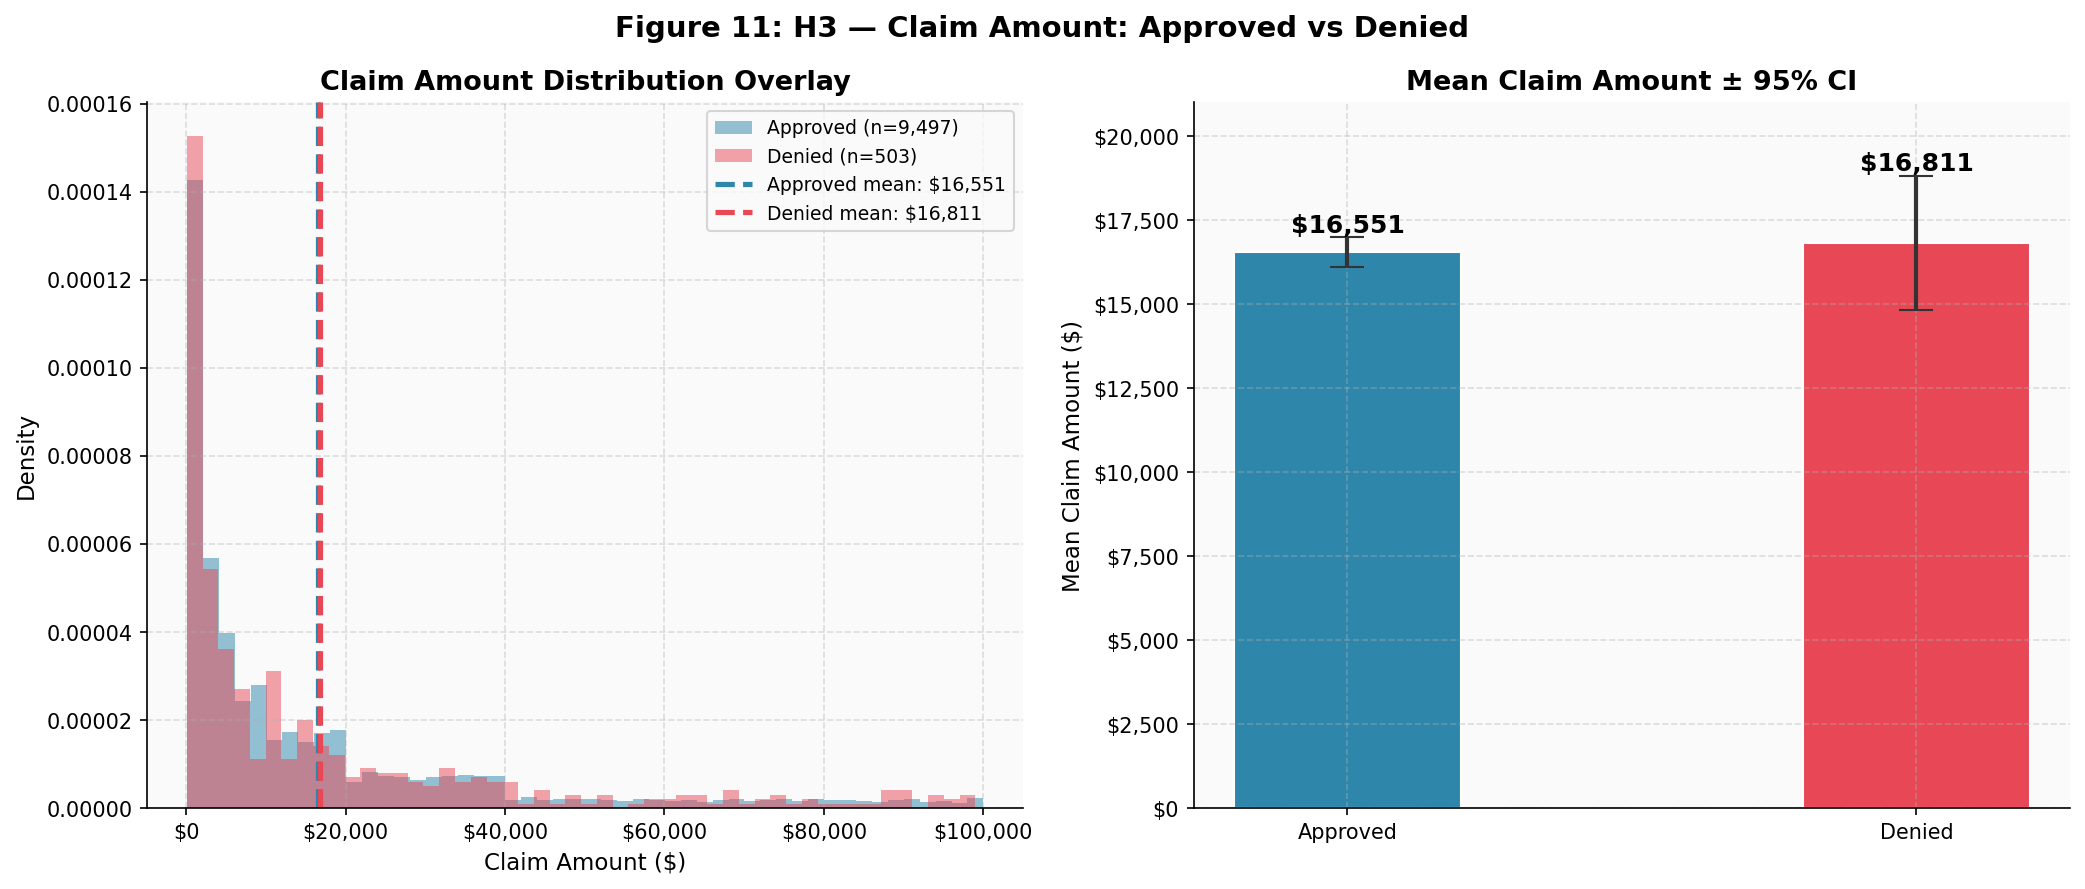

In [8]:
# ═══════════════════════════════════════════════════════════════
# 3.4 — H3: INDEPENDENT T-TEST (claim amount A vs D)
# ═══════════════════════════════════════════════════════════════

approved = df[df['CLAIM_STATUS']=='A']['CLAIM_AMOUNT']
denied   = df[df['CLAIM_STATUS']=='D']['CLAIM_AMOUNT']

h3_results = run_ttest(approved, denied,
                        label_a='Approved', label_b='Denied',
                        label='H3 — Claim Amount: Approved vs Denied')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 11: H3 — Claim Amount: Approved vs Denied', fontsize=14, fontweight='bold')

for label, data, color in [('Approved', approved, APPR_COLOR), ('Denied', denied, DENY_COLOR)]:
    axes[0].hist(data, bins=50, density=True, alpha=0.5, color=color,
                  label=f'{label} (n={len(data):,})', edgecolor='none')
axes[0].axvline(approved.mean(), color=APPR_COLOR, linestyle='--', linewidth=2.5,
                label=f'Approved mean: ${approved.mean():,.0f}')
axes[0].axvline(denied.mean(),   color=DENY_COLOR,  linestyle='--', linewidth=2.5,
                label=f'Denied mean: ${denied.mean():,.0f}')
axes[0].set_title('Claim Amount Distribution Overlay')
axes[0].set_xlabel('Claim Amount ($)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)
fmt_currency(axes[0], 'x')

means  = [approved.mean(), denied.mean()]
errors = [1.96*approved.sem(), 1.96*denied.sem()]
bars   = axes[1].bar(['Approved','Denied'], means, yerr=errors,
                      color=[APPR_COLOR,DENY_COLOR], width=0.4, edgecolor='white',
                      capsize=8, error_kw=dict(ecolor='#333', linewidth=2))
axes[1].set_title('Mean Claim Amount ± 95% CI')
axes[1].set_ylabel('Mean Claim Amount ($)')
fmt_currency(axes[1], 'y')
for bar, val, err in zip(bars, means, errors):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+err+150,
                 f'${val:,.0f}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, max(means)*1.25)

save_fig('fig11_h3_ttest.png')
plt.show()


**Result: FAIL TO REJECT H₀** (t=-0.258, p=0.797). Denied ≠ simply the largest claims.
**Fraud cannot be detected by claim size alone** — a rich multivariate model is required.

---

## 3.5 H4 — Report Lag Differs by Incident Severity

> **H₀:** Mean report lag is equal across Minor/Major/Total Loss
> **H₁:** Lag differs by severity
> **Test:** One-way ANOVA + Kruskal-Wallis


  ANOVA: H4 — Report Lag by Incident Severity
  F-statistic      :       1.4477
  ANOVA p-value    :   2.3516e-01
  Eta-squared (η²) :       0.0003
  Kruskal-Wallis H :       3.3430
  Kruskal p-value  :   1.8797e-01
  α                : 0.05
  Decision         : Fail to reject H₀

 Saved → reports/fig12_h4_anova_lag.png


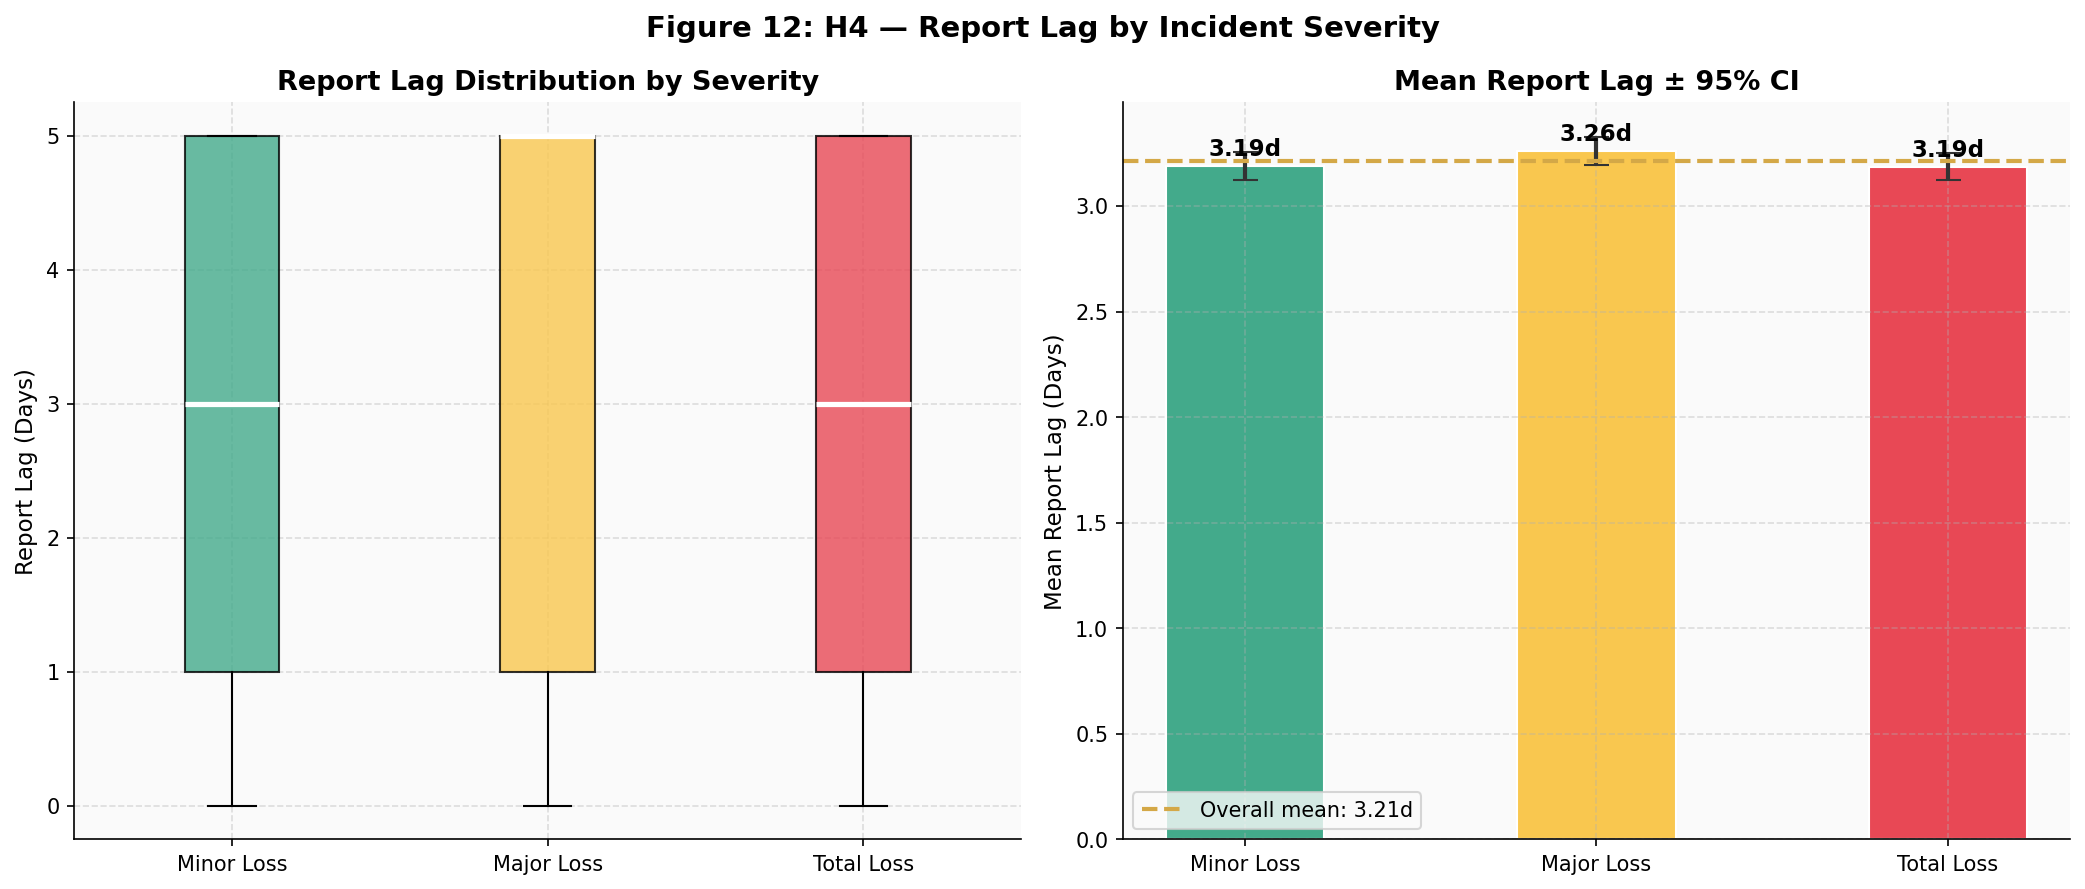

In [9]:
# ═══════════════════════════════════════════════════════════════
# 3.5 — H4: ANOVA ON REPORT LAG BY SEVERITY
# ═══════════════════════════════════════════════════════════════

h4_results = run_anova(df, group_col='INCIDENT_SEVERITY',
                        value_col='REPORT_LAG_DAYS',
                        label='H4 — Report Lag by Incident Severity')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 12: H4 — Report Lag by Incident Severity', fontsize=14, fontweight='bold')

sev_colors = ['#43AA8B', '#F9C74F', DENY_COLOR]
plot_lag   = [df[df['INCIDENT_SEVERITY']==s]['REPORT_LAG_DAYS'].values for s in SEVERITY_LEVELS]
bp2 = axes[0].boxplot(plot_lag, labels=SEVERITY_LEVELS, patch_artist=True,
                       medianprops=dict(color='white', linewidth=2.5),
                       flierprops=dict(marker='o', markersize=3, alpha=0.3))
for patch, color in zip(bp2['boxes'], sev_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0].set_title('Report Lag Distribution by Severity')
axes[0].set_ylabel('Report Lag (Days)')

sev_means = df.groupby('INCIDENT_SEVERITY')['REPORT_LAG_DAYS'].agg(['mean','sem'])
sev_means = sev_means.reindex(SEVERITY_LEVELS)
sev_bars = axes[1].bar(SEVERITY_LEVELS, sev_means['mean'],
                        yerr=1.96*sev_means['sem'], color=sev_colors,
                        width=0.45, edgecolor='white',
                        error_kw=dict(ecolor='#333', capsize=6, linewidth=2))
add_avg_line(axes[1], df['REPORT_LAG_DAYS'].mean(),
             label=f"Overall mean: {df['REPORT_LAG_DAYS'].mean():.2f}d", orient='h')
axes[1].set_title('Mean Report Lag ± 95% CI')
axes[1].set_ylabel('Mean Report Lag (Days)')
axes[1].legend()
for bar, val in zip(sev_bars, sev_means['mean']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{val:.2f}d', ha='center', fontsize=11, fontweight='bold')

save_fig('fig12_h4_anova_lag.png')
plt.show()


**Result: FAIL TO REJECT H₀** (F=1.448, p=0.235). Report lag does not differ by severity —
claimants file at the same speed regardless of incident type. Temporal features are weak predictors.

---

## 3.6 Hypothesis Testing Summary


In [10]:
# ═══════════════════════════════════════════════════════════════
# 3.6 — RESULTS SUMMARY TABLE
# ═══════════════════════════════════════════════════════════════

summary = pd.DataFrame([
    {
        'Hypothesis': 'H1: Claim amount equal across types',
        'Test': 'One-Way ANOVA',
        'Statistic': f"F={h1_results['f_stat']:,.2f}",
        'p-value': f"{h1_results['p_anova']:.2e}",
        'Decision': 'REJECT H₀ ✓',
        'Finding': 'Life >> Mobile (100× difference)'
    },
    {
        'Hypothesis': 'H2: Denial independent of risk segment',
        'Test': 'Chi-Square',
        'Statistic': f"χ²={h2_results['chi2']:.2f}",
        'p-value': f"{h2_results['p']:.3f}",
        'Decision': 'Fail to reject',
        'Finding': 'Risk score does not predict denial'
    },
    {
        'Hypothesis': 'H3: Claim amount equal A vs D',
        'Test': 't-test + MW',
        'Statistic': f"t={h3_results['t_stat']:.3f}",
        'p-value': f"{h3_results['p_ttest']:.3f}",
        'Decision': 'Fail to reject',
        'Finding': 'Denied ≠ simply the largest claims'
    },
    {
        'Hypothesis': 'H4: Report lag equal across severities',
        'Test': 'One-Way ANOVA',
        'Statistic': f"F={h4_results['f_stat']:.3f}",
        'p-value': f"{h4_results['p_anova']:.3f}",
        'Decision': 'Fail to reject',
        'Finding': 'Lag uniform — weak predictor'
    },
])

print("=" * 90)
print("  HYPOTHESIS TESTING RESULTS SUMMARY")
print("=" * 90)
print(summary.to_string(index=False))
print()
print("Conclusion: 3 of 4 null hypotheses retained.")
print("→ No single variable predicts denial. A multivariate model (Chapter 5) is required.")


  HYPOTHESIS TESTING RESULTS SUMMARY
                            Hypothesis          Test  Statistic  p-value       Decision                            Finding
   H1: Claim amount equal across types One-Way ANOVA F=5,229.78 0.00e+00    REJECT H₀ ✓   Life >> Mobile (100× difference)
H2: Denial independent of risk segment    Chi-Square    χ²=3.26    0.196 Fail to reject Risk score does not predict denial
         H3: Claim amount equal A vs D   t-test + MW   t=-0.258    0.797 Fail to reject Denied ≠ simply the largest claims
H4: Report lag equal across severities One-Way ANOVA    F=1.448    0.235 Fail to reject       Lag uniform — weak predictor

Conclusion: 3 of 4 null hypotheses retained.
→ No single variable predicts denial. A multivariate model (Chapter 5) is required.


---

## 3.7 Chapter 3 Summary

Three of four null hypotheses were retained - a finding that is itself the key result.
No single numeric variable or the insurer's existing risk score adequately identifies
denied claims. This directly motivates the construction of a logistic regression
fraud classifier in Chapter 5 that combines many weak signals into a predictive model.

**Next:** Chapter 4 — Publication-Quality Visualisations | Chapter 5 — Fraud Classification Model

---
